# Phase 5 – Production Experiment Results

Analysis of 1,440 simulation runs across four experiment sets:
1. **Exp 1**: Baseline policy comparison (P0, P1, P2 at K=20)
2. **Exp 2**: Fleet size sensitivity (K ∈ {15, 20, 25, 30, 35, 40})
3. **Exp 3**: Demand scaling sensitivity (δ ∈ {0.5–2.0})
4. **Exp 4**: Service time robustness (μ_s ∈ {20, 25, 30} min)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results" / "simulation" / "production"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})
sns.set_style("whitegrid")
PALETTE = {"P0": "#e74c3c", "P1": "#3498db", "P2": "#2ecc71"}

## Load All Results

In [2]:
exp1 = pd.read_csv(RESULTS_DIR / "exp1_policy_comparison.csv")
exp2 = pd.read_csv(RESULTS_DIR / "exp2_fleet_sensitivity.csv")
exp3 = pd.read_csv(RESULTS_DIR / "exp3_demand_sensitivity.csv")
exp4 = pd.read_csv(RESULTS_DIR / "exp4_service_robustness.csv")

print(f"Exp 1: {len(exp1)} rows  |  Exp 2: {len(exp2)} rows")
print(f"Exp 3: {len(exp3)} rows  |  Exp 4: {len(exp4)} rows")
print(f"Total: {len(exp1)+len(exp2)+len(exp3)+len(exp4)} runs")

Exp 1: 90 rows  |  Exp 2: 540 rows
Exp 3: 540 rows  |  Exp 4: 270 rows
Total: 1440 runs


## Helper Functions

In [3]:
def ci_summary(df, group_cols, metric_col, confidence=0.95):
    """Compute mean, std, and CI for a metric grouped by columns."""
    def _agg(x):
        n = len(x)
        m = x.mean()
        s = x.std(ddof=1) if n > 1 else 0
        if n > 1 and s > 0:
            t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
            margin = t_crit * s / np.sqrt(n)
        else:
            margin = 0
        return pd.Series({
            "mean": m, "std": s, "ci_lower": m - margin, "ci_upper": m + margin, "n": n
        })
    return df.groupby(group_cols)[metric_col].apply(_agg).unstack()


def paired_ttest(df, policy_a, policy_b, metric="mean_response_time"):
    """Paired t-test using CRN (same seeds)."""
    a = df[df["policy"] == policy_a].sort_values("replication")[metric].values
    b = df[df["policy"] == policy_b].sort_values("replication")[metric].values
    n = min(len(a), len(b))
    t_stat, p_val = stats.ttest_rel(a[:n], b[:n])
    diff = a[:n] - b[:n]
    d = diff.mean() / diff.std() if diff.std() > 0 else 0  # Cohen's d
    return {"t_stat": t_stat, "p_value": p_val, "cohens_d": d,
            "mean_diff": diff.mean(), "n": n}

---
## Experiment 1: Baseline Policy Comparison

In [4]:
print("=== Exp 1: Policy Comparison (K=20, baseline conditions) ===\n")
exp1_summary = ci_summary(exp1, "policy", "mean_response_time")
print("Mean Response Time (minutes):")
print(exp1_summary.round(3).to_string())

=== Exp 1: Policy Comparison (K=20, baseline conditions) ===

Mean Response Time (minutes):
         mean    std  ci_lower  ci_upper     n
policy                                        
P0      8.082  0.266     7.983     8.182  30.0
P1      2.634  0.047     2.617     2.652  30.0
P2      2.570  0.044     2.554     2.587  30.0


In [5]:
# Coverage summary
cov_summary = ci_summary(exp1, "policy", "coverage_8min")
print("\n8-Minute Coverage:")
print(cov_summary.round(4).to_string())


8-Minute Coverage:
          mean     std  ci_lower  ci_upper     n
policy                                          
P0      0.6444  0.0203    0.6368    0.6519  30.0
P1      0.9958  0.0025    0.9948    0.9967  30.0
P2      0.9962  0.0024    0.9954    0.9971  30.0


In [6]:
# Paired t-tests
print("\n--- Paired T-Tests (CRN) ---")
for pa, pb in [("P0", "P1"), ("P0", "P2"), ("P1", "P2")]:
    r = paired_ttest(exp1, pa, pb)
    sig = "***" if r["p_value"] < 0.001 else "**" if r["p_value"] < 0.01 else "*" if r["p_value"] < 0.05 else "ns"
    print(f"  {pa} vs {pb}: diff={r['mean_diff']:+.3f} min, t={r['t_stat']:.2f}, "
          f"p={r['p_value']:.4f} {sig}, Cohen's d={r['cohens_d']:.2f}")


--- Paired T-Tests (CRN) ---
  P0 vs P1: diff=+5.448 min, t=109.22, p=0.0000 ***, Cohen's d=20.28
  P0 vs P2: diff=+5.512 min, t=111.25, p=0.0000 ***, Cohen's d=20.66
  P1 vs P2: diff=+0.064 min, t=8.77, p=0.0000 ***, Cohen's d=1.63


/tmp/ipykernel_4974/818369822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=exp1, x="policy", y="mean_response_time", palette=PALETTE, ax=axes[0])
/tmp/ipykernel_4974/818369822.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=exp1, x="policy", y="coverage_8min", palette=PALETTE, ax=axes[1])
/tmp/ipykernel_4974/818369822.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=exp1, x="policy", y="p90_response_time", palette=PALETTE, ax=axes[2])


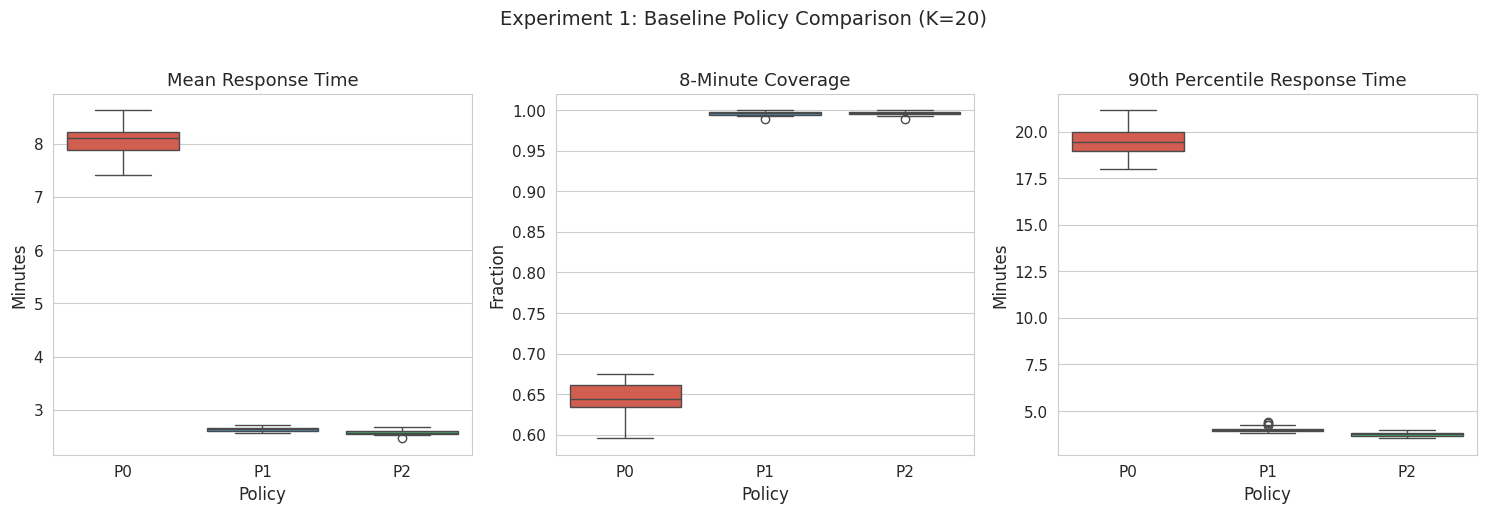

In [7]:
# Box plot – response time by policy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Response time
sns.boxplot(data=exp1, x="policy", y="mean_response_time", palette=PALETTE, ax=axes[0])
axes[0].set_title("Mean Response Time")
axes[0].set_ylabel("Minutes")
axes[0].set_xlabel("Policy")

# Coverage
sns.boxplot(data=exp1, x="policy", y="coverage_8min", palette=PALETTE, ax=axes[1])
axes[1].set_title("8-Minute Coverage")
axes[1].set_ylabel("Fraction")
axes[1].set_xlabel("Policy")

# P90 response time
sns.boxplot(data=exp1, x="policy", y="p90_response_time", palette=PALETTE, ax=axes[2])
axes[2].set_title("90th Percentile Response Time")
axes[2].set_ylabel("Minutes")
axes[2].set_xlabel("Policy")

fig.suptitle("Experiment 1: Baseline Policy Comparison (K=20)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Experiment 2: Fleet Size Sensitivity

In [8]:
print("=== Exp 2: Fleet Size Sensitivity ===\n")
exp2_rt = ci_summary(exp2, ["policy", "K"], "mean_response_time")
print("Mean Response Time by Policy × K:")
print(exp2_rt.round(3).to_string())

=== Exp 2: Fleet Size Sensitivity ===

Mean Response Time by Policy × K:
            mean    std  ci_lower  ci_upper     n
policy K                                         
P0     15  9.571  0.265     9.471     9.670  30.0
       20  8.082  0.266     7.983     8.182  30.0
       25  5.790  0.208     5.712     5.867  30.0
       30  3.918  0.138     3.866     3.969  30.0
       35  3.260  0.096     3.224     3.297  30.0
       40  2.583  0.042     2.567     2.599  30.0
P1     15  2.956  0.050     2.937     2.975  30.0
       20  2.634  0.047     2.617     2.652  30.0
       25  2.473  0.042     2.458     2.489  30.0
       30  2.397  0.038     2.383     2.412  30.0
       35  2.365  0.035     2.352     2.378  30.0
       40  2.349  0.032     2.337     2.361  30.0
P2     15  2.835  0.054     2.815     2.855  30.0
       20  2.570  0.044     2.554     2.587  30.0
       25  2.513  0.038     2.499     2.527  30.0
       30  2.510  0.038     2.496     2.524  30.0
       35  2.505  0.037    

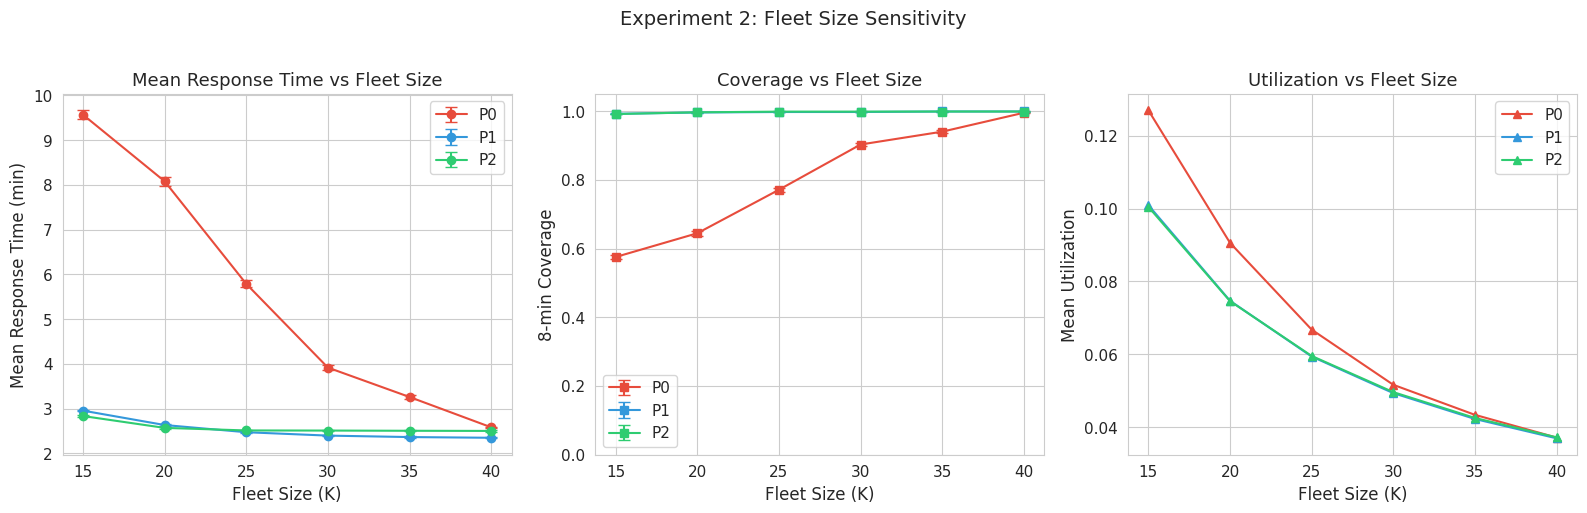

In [9]:
# Line plot: mean RT vs K
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for policy in ["P0", "P1", "P2"]:
    sub = exp2[exp2["policy"] == policy]
    grp = sub.groupby("K")["mean_response_time"].agg(["mean", "std", "count"]).reset_index()
    t_crit = stats.t.ppf(0.975, df=grp["count"] - 1)
    grp["ci"] = t_crit * grp["std"] / np.sqrt(grp["count"])

    axes[0].errorbar(grp["K"], grp["mean"], yerr=grp["ci"], marker="o",
                     label=policy, color=PALETTE[policy], capsize=4)

axes[0].set_xlabel("Fleet Size (K)")
axes[0].set_ylabel("Mean Response Time (min)")
axes[0].set_title("Mean Response Time vs Fleet Size")
axes[0].legend()

# Coverage vs K
for policy in ["P0", "P1", "P2"]:
    sub = exp2[exp2["policy"] == policy]
    grp = sub.groupby("K")["coverage_8min"].agg(["mean", "std", "count"]).reset_index()
    t_crit = stats.t.ppf(0.975, df=grp["count"] - 1)
    grp["ci"] = t_crit * grp["std"] / np.sqrt(grp["count"])

    axes[1].errorbar(grp["K"], grp["mean"], yerr=grp["ci"], marker="s",
                     label=policy, color=PALETTE[policy], capsize=4)

axes[1].set_xlabel("Fleet Size (K)")
axes[1].set_ylabel("8-min Coverage")
axes[1].set_title("Coverage vs Fleet Size")
axes[1].legend()
axes[1].set_ylim(0, 1.05)

# Utilization vs K
for policy in ["P0", "P1", "P2"]:
    sub = exp2[exp2["policy"] == policy]
    grp = sub.groupby("K")["mean_utilization"].agg(["mean"]).reset_index()
    axes[2].plot(grp["K"], grp["mean"], marker="^", label=policy, color=PALETTE[policy])

axes[2].set_xlabel("Fleet Size (K)")
axes[2].set_ylabel("Mean Utilization")
axes[2].set_title("Utilization vs Fleet Size")
axes[2].legend()

fig.suptitle("Experiment 2: Fleet Size Sensitivity", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp2_fleet_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Experiment 3: Demand Scaling Sensitivity

In [10]:
print("=== Exp 3: Demand Scaling Sensitivity ===\n")
exp3_rt = ci_summary(exp3, ["policy", "demand_multiplier"], "mean_response_time")
print("Mean Response Time by Policy × Demand Multiplier:")
print(exp3_rt.round(3).to_string())

=== Exp 3: Demand Scaling Sensitivity ===

Mean Response Time by Policy × Demand Multiplier:
                           mean    std  ci_lower  ci_upper     n
policy demand_multiplier                                        
P0     0.50               7.796  0.355     7.664     7.928  30.0
       0.75               8.048  0.393     7.901     8.195  30.0
       1.00               8.082  0.266     7.983     8.182  30.0
       1.25               8.309  0.295     8.199     8.419  30.0
       1.50               8.434  0.365     8.297     8.570  30.0
       2.00               8.577  0.297     8.466     8.687  30.0
P1     0.50               2.529  0.049     2.511     2.548  30.0
       0.75               2.588  0.061     2.565     2.611  30.0
       1.00               2.634  0.047     2.617     2.652  30.0
       1.25               2.670  0.044     2.653     2.686  30.0
       1.50               2.744  0.053     2.724     2.764  30.0
       2.00               2.867  0.056     2.846     2.888  30

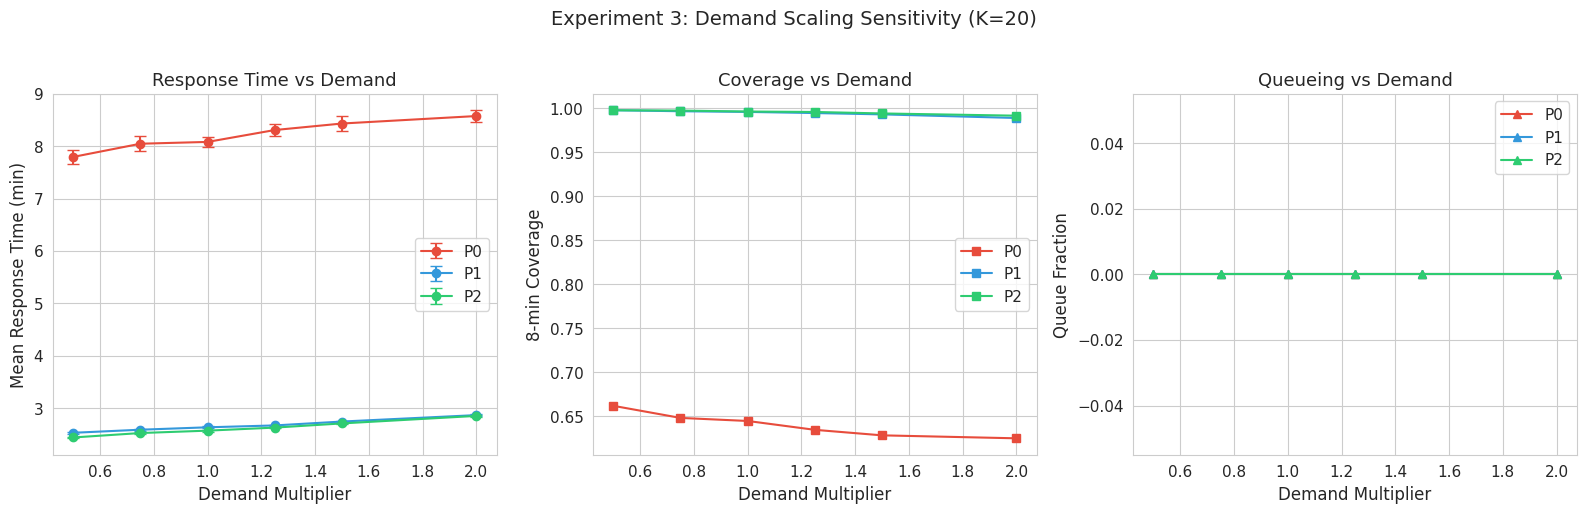

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RT vs demand multiplier
for policy in ["P0", "P1", "P2"]:
    sub = exp3[exp3["policy"] == policy]
    grp = sub.groupby("demand_multiplier")["mean_response_time"].agg(["mean", "std", "count"]).reset_index()
    t_crit = stats.t.ppf(0.975, df=grp["count"] - 1)
    grp["ci"] = t_crit * grp["std"] / np.sqrt(grp["count"])
    axes[0].errorbar(grp["demand_multiplier"], grp["mean"], yerr=grp["ci"],
                     marker="o", label=policy, color=PALETTE[policy], capsize=4)

axes[0].set_xlabel("Demand Multiplier")
axes[0].set_ylabel("Mean Response Time (min)")
axes[0].set_title("Response Time vs Demand")
axes[0].legend()

# Coverage vs demand
for policy in ["P0", "P1", "P2"]:
    sub = exp3[exp3["policy"] == policy]
    grp = sub.groupby("demand_multiplier")["coverage_8min"].agg(["mean"]).reset_index()
    axes[1].plot(grp["demand_multiplier"], grp["mean"], marker="s",
                 label=policy, color=PALETTE[policy])

axes[1].set_xlabel("Demand Multiplier")
axes[1].set_ylabel("8-min Coverage")
axes[1].set_title("Coverage vs Demand")
axes[1].legend()

# Queue fraction vs demand
for policy in ["P0", "P1", "P2"]:
    sub = exp3[exp3["policy"] == policy]
    grp = sub.groupby("demand_multiplier")["queue_fraction"].agg(["mean"]).reset_index()
    axes[2].plot(grp["demand_multiplier"], grp["mean"], marker="^",
                 label=policy, color=PALETTE[policy])

axes[2].set_xlabel("Demand Multiplier")
axes[2].set_ylabel("Queue Fraction")
axes[2].set_title("Queueing vs Demand")
axes[2].legend()

fig.suptitle("Experiment 3: Demand Scaling Sensitivity (K=20)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp3_demand_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Experiment 4: Service Time Robustness

In [12]:
print("=== Exp 4: Service Time Robustness ===\n")
exp4_rt = ci_summary(exp4, ["policy", "service_time_mean"], "mean_response_time")
print("Mean Response Time by Policy × Service Time Mean:")
print(exp4_rt.round(3).to_string())

=== Exp 4: Service Time Robustness ===

Mean Response Time by Policy × Service Time Mean:
                           mean    std  ci_lower  ci_upper     n
policy service_time_mean                                        
P0     20.0               8.018  0.262     7.921     8.116  30.0
       25.0               8.082  0.266     7.983     8.182  30.0
       30.0               8.139  0.252     8.045     8.233  30.0
P1     20.0               2.595  0.044     2.579     2.611  30.0
       25.0               2.634  0.047     2.617     2.652  30.0
       30.0               2.674  0.045     2.657     2.691  30.0
P2     20.0               2.522  0.038     2.507     2.536  30.0
       25.0               2.570  0.044     2.554     2.587  30.0
       30.0               2.620  0.051     2.601     2.639  30.0


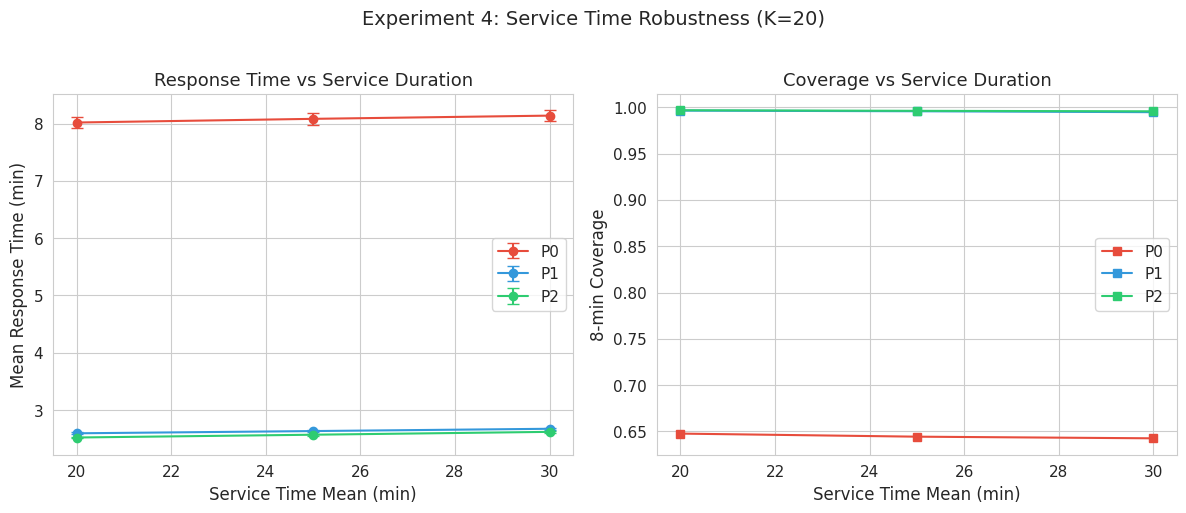

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RT by service time
for policy in ["P0", "P1", "P2"]:
    sub = exp4[exp4["policy"] == policy]
    grp = sub.groupby("service_time_mean")["mean_response_time"].agg(["mean", "std", "count"]).reset_index()
    t_crit = stats.t.ppf(0.975, df=grp["count"] - 1)
    grp["ci"] = t_crit * grp["std"] / np.sqrt(grp["count"])
    axes[0].errorbar(grp["service_time_mean"], grp["mean"], yerr=grp["ci"],
                     marker="o", label=policy, color=PALETTE[policy], capsize=4)

axes[0].set_xlabel("Service Time Mean (min)")
axes[0].set_ylabel("Mean Response Time (min)")
axes[0].set_title("Response Time vs Service Duration")
axes[0].legend()

# Coverage by service time
for policy in ["P0", "P1", "P2"]:
    sub = exp4[exp4["policy"] == policy]
    grp = sub.groupby("service_time_mean")["coverage_8min"].agg(["mean"]).reset_index()
    axes[1].plot(grp["service_time_mean"], grp["mean"], marker="s",
                 label=policy, color=PALETTE[policy])

axes[1].set_xlabel("Service Time Mean (min)")
axes[1].set_ylabel("8-min Coverage")
axes[1].set_title("Coverage vs Service Duration")
axes[1].legend()

fig.suptitle("Experiment 4: Service Time Robustness (K=20)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp4_service_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Combined Summary Table

In [14]:
# Build comprehensive summary table
def build_summary_table(df, exp_name, extra_cols=None):
    """Build a summary table with CIs for all key metrics."""
    group_cols = ["policy"]
    if extra_cols:
        group_cols = group_cols + extra_cols

    metrics = {
        "mean_response_time": "Mean RT (min)",
        "p90_response_time": "P90 RT (min)",
        "coverage_8min": "8-min Coverage",
        "mean_utilization": "Mean Utilization",
        "queue_fraction": "Queue Fraction",
    }

    rows = []
    for name, grp in df.groupby(group_cols):
        if not isinstance(name, tuple):
            name = (name,)
        row = dict(zip(group_cols, name))
        row["n_reps"] = len(grp)
        for col, label in metrics.items():
            vals = grp[col].values
            m = vals.mean()
            s = vals.std(ddof=1) if len(vals) > 1 else 0
            n = len(vals)
            if n > 1 and s > 0:
                t_c = stats.t.ppf(0.975, df=n - 1)
                margin = t_c * s / np.sqrt(n)
            else:
                margin = 0
            row[f"{label}"] = f"{m:.3f}"
            row[f"{label} 95% CI"] = f"[{m-margin:.3f}, {m+margin:.3f}]"
        rows.append(row)

    return pd.DataFrame(rows)


# Exp 1 summary table
print("=== Experiment 1 Summary ===")
t1 = build_summary_table(exp1, "exp1")
print(t1.to_string(index=False))
t1.to_csv(TABLES_DIR / "exp1_summary.csv", index=False)

=== Experiment 1 Summary ===
policy  n_reps Mean RT (min) Mean RT (min) 95% CI P90 RT (min) P90 RT (min) 95% CI 8-min Coverage 8-min Coverage 95% CI Mean Utilization Mean Utilization 95% CI Queue Fraction Queue Fraction 95% CI
    P0      30         8.082       [7.983, 8.182]       19.475    [19.225, 19.724]          0.644        [0.637, 0.652]            0.091          [0.089, 0.092]          0.000        [0.000, 0.000]
    P1      30         2.634       [2.617, 2.652]        4.031      [3.976, 4.086]          0.996        [0.995, 0.997]            0.075          [0.074, 0.076]          0.000        [0.000, 0.000]
    P2      30         2.570       [2.554, 2.587]        3.760      [3.717, 3.803]          0.996        [0.995, 0.997]            0.075          [0.073, 0.076]          0.000        [0.000, 0.000]


In [15]:
# Exp 2 pivot table
print("\n=== Experiment 2: Mean RT by Policy × K ===")
t2_pivot = exp2.pivot_table(
    values="mean_response_time", index="K", columns="policy", aggfunc="mean"
)[["P0", "P1", "P2"]]
print(t2_pivot.round(3).to_string())
t2_pivot.to_csv(TABLES_DIR / "exp2_pivot_rt.csv")


=== Experiment 2: Mean RT by Policy × K ===
policy     P0     P1     P2
K                          
15      9.571  2.956  2.835
20      8.082  2.634  2.570
25      5.790  2.473  2.513
30      3.918  2.397  2.510
35      3.260  2.365  2.505
40      2.583  2.349  2.502


In [16]:
# Exp 3 pivot table
print("\n=== Experiment 3: Mean RT by Policy × Demand Multiplier ===")
t3_pivot = exp3.pivot_table(
    values="mean_response_time", index="demand_multiplier", columns="policy", aggfunc="mean"
)[["P0", "P1", "P2"]]
print(t3_pivot.round(3).to_string())
t3_pivot.to_csv(TABLES_DIR / "exp3_pivot_rt.csv")


=== Experiment 3: Mean RT by Policy × Demand Multiplier ===
policy                P0     P1     P2
demand_multiplier                     
0.50               7.796  2.529  2.440
0.75               8.048  2.588  2.525
1.00               8.082  2.634  2.570
1.25               8.309  2.670  2.628
1.50               8.434  2.744  2.708
2.00               8.577  2.867  2.852


In [17]:
# Exp 4 summary
print("\n=== Experiment 4: Mean RT by Policy × Service Time ===")
t4_pivot = exp4.pivot_table(
    values="mean_response_time", index="service_time_mean", columns="policy", aggfunc="mean"
)[["P0", "P1", "P2"]]
print(t4_pivot.round(3).to_string())
t4_pivot.to_csv(TABLES_DIR / "exp4_pivot_rt.csv")


=== Experiment 4: Mean RT by Policy × Service Time ===
policy                P0     P1     P2
service_time_mean                     
20.0               8.018  2.595  2.522
25.0               8.082  2.634  2.570
30.0               8.139  2.674  2.620


---
## Key Findings

In [18]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Exp 1 findings
p0_rt = exp1[exp1["policy"] == "P0"]["mean_response_time"].mean()
p1_rt = exp1[exp1["policy"] == "P1"]["mean_response_time"].mean()
p2_rt = exp1[exp1["policy"] == "P2"]["mean_response_time"].mean()
print(f"\n1. Baseline Policy Comparison (K=20):")
print(f"   P0 mean RT: {p0_rt:.2f} min | P1: {p1_rt:.2f} min | P2: {p2_rt:.2f} min")
print(f"   P2 improvement over P0: {(1-p2_rt/p0_rt)*100:.1f}%")
print(f"   P2 improvement over P1: {(1-p2_rt/p1_rt)*100:.1f}%")

# Exp 2 findings
print(f"\n2. Fleet Size Sensitivity:")
for K in sorted(exp2["K"].unique()):
    p2_val = exp2[(exp2["policy"]=="P2") & (exp2["K"]==K)]["mean_response_time"].mean()
    p0_val = exp2[(exp2["policy"]=="P0") & (exp2["K"]==K)]["mean_response_time"].mean()
    print(f"   K={K:2d}: P0={p0_val:.2f}, P2={p2_val:.2f} min (P2 advantage: {p0_val-p2_val:.2f} min)")

# Exp 3 findings
print(f"\n3. Demand Scaling Sensitivity:")
for dm in sorted(exp3["demand_multiplier"].unique()):
    p2_val = exp3[(exp3["policy"]=="P2") & (exp3["demand_multiplier"]==dm)]["mean_response_time"].mean()
    p0_val = exp3[(exp3["policy"]=="P0") & (exp3["demand_multiplier"]==dm)]["mean_response_time"].mean()
    print(f"   δ={dm:.2f}: P0={p0_val:.2f}, P2={p2_val:.2f} min")

# Exp 4 findings
print(f"\n4. Service Time Robustness:")
for sm in sorted(exp4["service_time_mean"].unique()):
    p2_val = exp4[(exp4["policy"]=="P2") & (exp4["service_time_mean"]==sm)]["mean_response_time"].mean()
    p0_val = exp4[(exp4["policy"]=="P0") & (exp4["service_time_mean"]==sm)]["mean_response_time"].mean()
    print(f"   μ_s={sm:.0f} min: P0={p0_val:.2f}, P2={p2_val:.2f} min")

print(f"\n{'='*60}")
print("All production experiments completed successfully.")
print(f"Total runs: {len(exp1)+len(exp2)+len(exp3)+len(exp4)}")

KEY FINDINGS

1. Baseline Policy Comparison (K=20):
   P0 mean RT: 8.08 min | P1: 2.63 min | P2: 2.57 min
   P2 improvement over P0: 68.2%
   P2 improvement over P1: 2.4%

2. Fleet Size Sensitivity:
   K=15: P0=9.57, P2=2.84 min (P2 advantage: 6.74 min)
   K=20: P0=8.08, P2=2.57 min (P2 advantage: 5.51 min)
   K=25: P0=5.79, P2=2.51 min (P2 advantage: 3.28 min)
   K=30: P0=3.92, P2=2.51 min (P2 advantage: 1.41 min)
   K=35: P0=3.26, P2=2.51 min (P2 advantage: 0.76 min)
   K=40: P0=2.58, P2=2.50 min (P2 advantage: 0.08 min)

3. Demand Scaling Sensitivity:
   δ=0.50: P0=7.80, P2=2.44 min
   δ=0.75: P0=8.05, P2=2.52 min
   δ=1.00: P0=8.08, P2=2.57 min
   δ=1.25: P0=8.31, P2=2.63 min
   δ=1.50: P0=8.43, P2=2.71 min
   δ=2.00: P0=8.58, P2=2.85 min

4. Service Time Robustness:
   μ_s=20 min: P0=8.02, P2=2.52 min
   μ_s=25 min: P0=8.08, P2=2.57 min
   μ_s=30 min: P0=8.14, P2=2.62 min

All production experiments completed successfully.
Total runs: 1440
